# Build and train MicNet

In [ ]:
import matplotlib.pyplot as plt
import os
import math
import numpy as np
import pandas as pd
import re
import sys

import skimage

import time
import torch
import torch.hub
import torch.nn
import tifffile

from MicNet_model import *
from utils_data import Dataset
from utils_data import normalize, augmentor
from utils_eval import NCESoftmaxLoss, NCECriterion

## 1) Load data

(11607, 11620, 3)


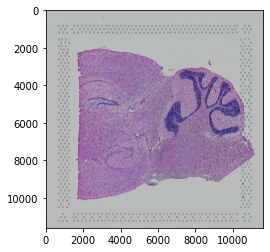

In [7]:
count_stat = pd.read_csv("./output/Dataset_MPB/1_count_stat_mouse_brain.csv", index_col=0)
count = pd.read_csv("./output/Dataset_MPB/1_pd_count_norm_mouse_brain.csv", index_col=0)

image_file = "./Sample_data/Dataset_MPB/V1_Mouse_Brain_Sagittal_Posterior_image.tif"
image = tifffile.imread(os.path.join(image_file))
print(image.shape)
image_norm = image.copy()
plt.imshow(image_norm)
plt.show()

In [8]:
transformation_file = "./Sample_data/Dataset_MPB/mouse_brain_serial_sagittal_posterior_section1.loc.csv"
pd_meta = pd.read_table(transformation_file, sep=",")
print(pd_meta.shape)
print(count.shape)
pd_meta.columns = ['X', 'Y']
pd_meta

(3355, 2)
(3355, 21353)


,X,Y
0,7409,8455
1,8487,2740
2,3096,7905
3,6570,2052
4,7050,2327
...,...,...
3350,4294,5839
3351,5133,6734
3352,8368,4324
3353,8607,3498


In [55]:
# Split training and testing
np.random.seed(82321)
indexes_all = pd_meta.index.values
training_indexes = np.random.choice(indexes_all, int(len(indexes_all) * 0.95), replace=False)
testing_indexes = [_ for _ in indexes_all if _ not in training_indexes]
print("#Training: {}, #Testing: {}".format(len(training_indexes), len(testing_indexes)))
training_indexes.sort()
testing_indexes.sort()

#Training: 3187, #Testing: 168


In [57]:
# Log2
count = np.log2(count + 1)

# Normalize gene_stat by divided with max
count_max = np.log2(count_stat.loc['max', :].values + 1)
count_max[count_max < 1] = 1
count = count/count_max

In [58]:
count

,0610005C13Rik,0610009B22Rik,0610009E02Rik,0610009L18Rik,0610010F05Rik,0610010K14Rik,0610012G03Rik,0610025J13Rik,0610030E20Rik,0610033M10Rik,...,mt-Co2,mt-Co3,mt-Cytb,mt-Nd1,mt-Nd2,mt-Nd3,mt-Nd4,mt-Nd4l,mt-Nd5,mt-Nd6
0,0.0,0.075250,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.108384,0.0,...,0.057990,0.055664,0.060125,0.062859,0.061620,0.067664,0.051791,0.044839,0.057542,0.000000
1,0.0,0.000000,0.0,0.043611,0.000000,0.057821,0.073422,0.0,0.000000,0.0,...,0.057567,0.054728,0.059440,0.062811,0.061971,0.068663,0.051223,0.045525,0.057249,0.000000
2,0.0,0.065596,0.0,0.049130,0.000000,0.056087,0.075113,0.0,0.000000,0.0,...,0.057746,0.055372,0.061232,0.063645,0.063085,0.067942,0.053927,0.054664,0.060962,0.079237
3,0.0,0.070502,0.0,0.000000,0.062735,0.060345,0.071136,0.0,0.000000,0.0,...,0.058236,0.056756,0.062020,0.065906,0.064258,0.069542,0.054159,0.052408,0.059172,0.000000
4,0.0,0.080440,0.0,0.000000,0.000000,0.061569,0.072556,0.0,0.000000,0.0,...,0.058274,0.055822,0.060155,0.064022,0.063509,0.065917,0.052914,0.051117,0.056559,0.086716
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3350,0.0,0.000000,0.0,0.000000,0.000000,0.059284,0.000000,0.0,0.000000,0.0,...,0.057973,0.056182,0.060617,0.062984,0.063392,0.067963,0.053018,0.051711,0.059363,0.000000
3351,0.0,0.074670,0.0,0.049310,0.058533,0.068289,0.075338,0.0,0.095298,0.0,...,0.046880,0.048179,0.050783,0.054628,0.051966,0.052232,0.044430,0.000000,0.042647,0.079515
3352,0.0,0.068430,0.0,0.000000,0.000000,0.050608,0.074238,0.0,0.000000,0.0,...,0.056930,0.054930,0.059588,0.061633,0.061377,0.065709,0.051450,0.047723,0.056377,0.071724
3353,0.0,0.000000,0.0,0.050142,0.000000,0.000000,0.081341,0.0,0.000000,0.0,...,0.058503,0.056580,0.060811,0.064318,0.062862,0.069561,0.053274,0.052002,0.060127,0.000000


In [59]:
PATCH_SIZE = 256

## 2) Check data loader

In [60]:
# from utils_data import Dataset
from utils_data import normalize, augmentor

import numpy as np
import math
import skimage
import skimage.transform

import torch
import torch.utils
import torch.utils.data
    
# Get image patch
def get_image_patch(image, coords, patch_size):
    """
    Args:
        coords: center of image; x, y (col, row) in pixels
    """
    row_start = int(coords[1] - patch_size/2)
    col_start = int(coords[0] - patch_size/2)
    return image[row_start:row_start + patch_size, col_start:col_start + patch_size]

class Dataset(torch.utils.data.Dataset):
    __initialized = False
    def __init__(self, indexes, image, count_df, meta_df, augmentation=False):
        """
        Args:
            indexes: index used for both count_df and meta_df
        """
        self.indexes = indexes
        self.image = image
        self.count_df = count_df
        self.meta_df = meta_df
        self.augmentation = augmentation
        self.__initialized = True

    def __len__(self):
        """Denotes the number of samples"""
        return len(self.indexes)
    
    def __getitem__(self, index):
        """Generate one batch of data.
        
        Returns:
            index: indexes of samples (long)
        """
        # Generate data
        data = self.__data_generation(self.indexes[index])

        return data, index
    
    def __data_generation(self, indexes):
        """Generates data containing batch_size samples.
        
        Returns:
            data: a dictionary with data.image in [b, ch, h, w]; data.gene in [b, n_genes]
        """
        image = get_image_patch(self.image, 
                                [self.meta_df.loc[indexes, "Y"], self.meta_df.loc[indexes, "X"]], 
                                PATCH_SIZE)  # meta_df mistakes X/Y
        if self.augmentation:
            image = augmentor(normalize(image))
        else:
            image = normalize(image)
        
        data = dict()
        data['image'] = torch.tensor(np.transpose(image, (2, 0, 1)).astype(float))
        data['gene'] = torch.tensor(self.count_df.loc[indexes, :].values)
        
        return data 

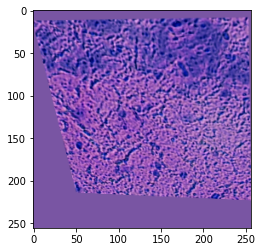

tensor([2135])


In [61]:
# Generator
np.random.seed()
train_set = Dataset(training_indexes, image_norm, count, pd_meta, augmentation=True)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=1, shuffle=True, num_workers=1)
for x, y in train_loader:
    plt.imshow(normalize(np.transpose(x['image'][0].numpy(), (1, 2, 0)), inverse=True))
    plt.show()
    print(y)
    break

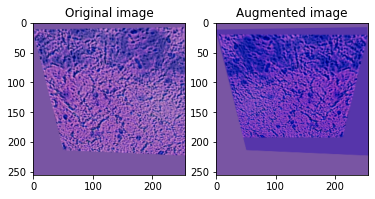

In [62]:
image = normalize(np.transpose(x['image'][0].numpy(), (1, 2, 0)), inverse=True)
plt.subplot(121)
plt.imshow(image)
plt.title("Original image")
plt.subplot(122)
plt.imshow(normalize(augmentor(normalize(image)), inverse=True))
plt.title("Augmented image")
plt.show()

## 3) Create network

In [64]:
from torch.nn.modules import MSELoss
device = torch.device("cuda:0")
image_shape = PATCH_SIZE
n_genes = count_stat.shape[1]
n_data = len(training_indexes)
n_out_features = 100
imagenet = 'resnet101'

# NCE parameters
nce_k = 100
nce_t = 0.07
nce_m = 0.9
softmax = False

# Training parameters
lr = 0.01  
momentum = 0.9
weight_decay = 0.0001
gradient_clip = 5

# Generator
train_set = Dataset(training_indexes, image_norm, count, pd_meta, augmentation=True)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=20, shuffle=True, num_workers=1)
test_set = Dataset(testing_indexes, image_norm, count, pd_meta, augmentation=False)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=20, shuffle=False, num_workers=1)

# Set model
model = MicNet(image_shape=image_shape, n_genes=n_genes, n_out_features=n_out_features, 
               imagenet=imagenet, genenet=[500, 100]).to(device)
contrast = NCEAverage(n_out_features, n_data, nce_k, nce_t, nce_m, softmax, device=device).to(device)
criterion_image = NCESoftmaxLoss().to(device) if softmax else NCECriterion(n_data).to(device)
criterion_gene = NCESoftmaxLoss().to(device) if softmax else NCECriterion(n_data).to(device)

# Set optimizer
optimizer = torch.optim.SGD(model.parameters(),
                            lr=lr,
                            momentum=momentum,
                            weight_decay=weight_decay)

Using cache found in /home2/swan15/.cache/torch/hub/pytorch_vision_v0.4.0


In [65]:
model_dir = "./models/Dataset_MPB"
if not os.path.exists(model_dir):
    os.mkdir(model_dir)

In [66]:
model

IGCNet(
  (imagenet): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          

In [67]:
"""TO LOAD:"""
model_file = None
if model_file is not None:
    print("=> loading checkpoint '{}'".format(model_file))
    checkpoint = torch.load(model_file, map_location=device)
    start_epoch = checkpoint['epoch'] + 1
    model.load_state_dict(checkpoint['model'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    contrast.load_state_dict(checkpoint['contrast'])
    del checkpoint

## 4) Train

In [68]:
import time
from scipy.stats import spearmanr

from utils_eval import AverageMeter

def train(epoch, train_loader, model, contrast, criterion_image, criterion_gene, optimizer, 
          gradient_clip=10, print_freq=1, device=torch.device("cuda:0")):
    """
    One epoch training
    """
    model.train()
    contrast.train()

    batch_time = AverageMeter()
    data_time = AverageMeter()
    losses = AverageMeter()
    image_loss_meter = AverageMeter()
    gene_loss_meter = AverageMeter()
    image_prob_meter = AverageMeter()
    gene_prob_meter = AverageMeter()

    end = time.time()
    for idx, (data, index) in enumerate(train_loader):
        data_time.update(time.time() - end)

        batch_size = data['image'].size(0)
        index = index.to(device)
        for _ in data.keys():
            data[_] = data[_].float().to(device)

        # ===================forward=====================
        feat_image, feat_gene = model(data)
        out_image, out_gene = contrast(feat_image, feat_gene, index)
        
        # print("features:", feat_image, feat_gene, "\n")
        # print("outs: ", out_image, out_gene, "\n")
        
        image_loss = criterion_image(out_image)
        gene_loss = criterion_gene(out_gene)
        image_prob = out_image[:, 0].mean()
        gene_prob = out_gene[:, 0].mean()

        loss = image_loss + gene_loss

        # ===================backward=====================
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip)
        torch.nn.utils.clip_grad_norm_(contrast.parameters(), gradient_clip)
        optimizer.step()

        # ===================meters=====================
        losses.update(loss.item(), batch_size)
        image_loss_meter.update(image_loss.item(), batch_size)
        image_prob_meter.update(image_prob.item(), batch_size)
        gene_loss_meter.update(gene_loss.item(), batch_size)
        gene_prob_meter.update(gene_prob.item(), batch_size)

        torch.cuda.synchronize()
        batch_time.update(time.time() - end)
        end = time.time()

        # print info
        if (idx + 1) % print_freq == 0:
            print('Epoch: [{0}][{1}/{2}]\t'
                  # 'BT {batch_time.val:.3f} ({batch_time.avg:.3f})\t'
                  # 'DT {data_time.val:.3f} ({data_time.avg:.3f})\t'
                  'loss {loss.val:.3f} ({loss.avg:.3f})\t'
                  'image_p {image_probs.val:.3f} ({image_probs.avg:.3f})\t'
                  'gene_p {gene_probs.val:.3f} ({gene_probs.avg:.3f})'.format(
                   epoch, idx + 1, len(train_loader), batch_time=batch_time,
                   data_time=data_time, 
                   loss=losses, 
                   image_probs=image_prob_meter,
                   gene_probs=gene_prob_meter))
            # print(out_image.shape)
            sys.stdout.flush()
            
        # ===================debug======================
        if np.isnan(image_prob_meter.val):
            print(list(model.parameters()))
            print(feat_image)
            print(feat_gene)
            print(out_image)
            
            raise Exception("Nan detected")
            break

    return losses.avg, image_loss_meter.avg, image_prob_meter.avg, gene_loss_meter.avg, gene_prob_meter.avg


def test(epoch, test_loader, model, contrast, criterion_image, criterion_gene, optimizer, 
          gradient_clip=10, print_freq=1, device=torch.device("cuda:0")):
    """Testing"""
    model.eval()
    contrast.eval()

    batch_time = AverageMeter()
    data_time = AverageMeter()

    end = time.time()
    for idx, (data, index) in enumerate(test_loader):
        data_time.update(time.time() - end)

        batch_size = data['image'].size(0)
        index = index.to(device)
        for _ in data.keys():
            data[_] = data[_].float().to(device)

        # ===================forward=====================
        with torch.no_grad():
            feat_image, feat_gene = model(data)
        
        # Append
        if idx == 0:
            feat_images = feat_image.cpu().numpy()
            feat_genes = feat_gene.cpu().numpy()
        else:
            feat_images = np.concatenate([feat_images, feat_image.cpu().numpy()])
            feat_genes = np.concatenate([feat_genes, feat_gene.cpu().numpy()])
        
        torch.cuda.synchronize()
        batch_time.update(time.time() - end)
        end = time.time()
        
    # Normalize & calculate correlation
    feat_images = feat_images / np.sum(feat_images ** 2, axis=1, keepdims=True) ** 0.5
    feat_genes = feat_genes / np.sum(feat_genes ** 2, axis=1, keepdims=True) ** 0.5
    corr = []
    for i in range(feat_images.shape[1]):
        corr.append(spearmanr(feat_images[:, i], feat_genes[:, i]).correlation)
    if epoch % 100 == 0:
        plt.hist(corr, bins=30)
        plt.show()
    print("Val epoch {}, average corr {}".format(epoch, np.average(corr)))

    return np.average(corr)

Epoch: [0][10/160]	loss 55.184 (56.497)	image_p 0.008 (0.010)	gene_p 0.009 (0.009)
Epoch: [0][20/160]	loss 44.170 (52.117)	image_p 0.005 (0.010)	gene_p 0.009 (0.009)
Epoch: [0][30/160]	loss 48.439 (49.688)	image_p 0.000 (0.007)	gene_p 0.008 (0.009)
Epoch: [0][40/160]	loss 43.940 (48.479)	image_p 0.000 (0.007)	gene_p 0.004 (0.008)
Epoch: [0][50/160]	loss 41.011 (47.135)	image_p 0.006 (0.006)	gene_p 0.003 (0.007)
Epoch: [0][60/160]	loss 40.451 (46.121)	image_p 0.004 (0.006)	gene_p 0.002 (0.007)
Epoch: [0][70/160]	loss 39.290 (45.272)	image_p 0.001 (0.006)	gene_p 0.003 (0.006)
Epoch: [0][80/160]	loss 35.871 (44.462)	image_p 0.003 (0.006)	gene_p 0.005 (0.006)
Epoch: [0][90/160]	loss 38.172 (43.699)	image_p 0.010 (0.008)	gene_p 0.012 (0.006)
Epoch: [0][100/160]	loss 36.962 (42.962)	image_p 0.002 (0.009)	gene_p 0.006 (0.006)
Epoch: [0][110/160]	loss 34.723 (42.267)	image_p 0.015 (0.011)	gene_p 0.007 (0.006)
Epoch: [0][120/160]	loss 34.397 (41.555)	image_p 0.023 (0.013)	gene_p 0.005 (0.006)
E

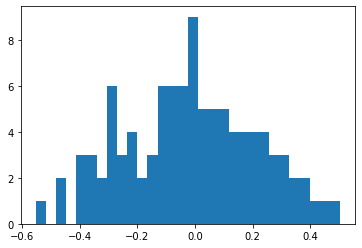

Val epoch 0, average corr -0.014368929090255677
Epoch: [1][10/160]	loss 35.890 (36.477)	image_p 0.000 (0.012)	gene_p 0.000 (0.008)
Epoch: [1][20/160]	loss 30.058 (34.234)	image_p 0.002 (0.010)	gene_p 0.052 (0.017)
Epoch: [1][30/160]	loss 30.374 (32.887)	image_p 0.016 (0.012)	gene_p 0.000 (0.016)
Epoch: [1][40/160]	loss 31.326 (31.952)	image_p 0.033 (0.013)	gene_p 0.004 (0.016)
Epoch: [1][50/160]	loss 28.259 (31.285)	image_p 0.003 (0.011)	gene_p 0.004 (0.015)
Epoch: [1][60/160]	loss 26.868 (30.561)	image_p 0.011 (0.012)	gene_p 0.029 (0.015)
Epoch: [1][70/160]	loss 27.128 (29.960)	image_p 0.014 (0.012)	gene_p 0.042 (0.016)
Epoch: [1][80/160]	loss 24.281 (29.473)	image_p 0.038 (0.013)	gene_p 0.050 (0.017)
Epoch: [1][90/160]	loss 26.867 (29.035)	image_p 0.003 (0.014)	gene_p 0.051 (0.018)
Epoch: [1][100/160]	loss 25.746 (28.640)	image_p 0.012 (0.015)	gene_p 0.077 (0.021)
Epoch: [1][110/160]	loss 23.092 (28.234)	image_p 0.062 (0.017)	gene_p 0.030 (0.022)
Epoch: [1][120/160]	loss 24.577 (27.8

Epoch: [6][160/160]	loss 6.207 (23.898)	image_p 0.863 (0.120)	gene_p 0.626 (0.101)
Val epoch 6, average corr 0.31581817767676823
Epoch: [7][10/160]	loss 31.170 (30.769)	image_p 0.030 (0.036)	gene_p 0.060 (0.049)
Epoch: [7][20/160]	loss 30.651 (30.192)	image_p 0.008 (0.029)	gene_p 0.013 (0.044)
Epoch: [7][30/160]	loss 25.646 (29.510)	image_p 0.143 (0.035)	gene_p 0.014 (0.039)
Epoch: [7][40/160]	loss 26.804 (28.961)	image_p 0.039 (0.036)	gene_p 0.023 (0.039)
Epoch: [7][50/160]	loss 24.845 (28.795)	image_p 0.095 (0.037)	gene_p 0.040 (0.040)
Epoch: [7][60/160]	loss 29.394 (28.512)	image_p 0.005 (0.040)	gene_p 0.001 (0.040)
Epoch: [7][70/160]	loss 23.860 (27.997)	image_p 0.080 (0.042)	gene_p 0.111 (0.040)
Epoch: [7][80/160]	loss 25.915 (27.739)	image_p 0.025 (0.043)	gene_p 0.035 (0.041)
Epoch: [7][90/160]	loss 22.690 (27.454)	image_p 0.050 (0.046)	gene_p 0.102 (0.043)
Epoch: [7][100/160]	loss 26.094 (27.141)	image_p 0.071 (0.048)	gene_p 0.054 (0.046)
Epoch: [7][110/160]	loss 23.879 (26.710)

Epoch: [12][150/160]	loss 15.406 (22.745)	image_p 0.330 (0.116)	gene_p 0.251 (0.084)
Epoch: [12][160/160]	loss 9.401 (22.079)	image_p 0.938 (0.143)	gene_p 0.477 (0.100)
Val epoch 12, average corr 0.5623801256320834
Epoch: [13][10/160]	loss 26.526 (28.121)	image_p 0.050 (0.047)	gene_p 0.055 (0.039)
Epoch: [13][20/160]	loss 26.524 (27.175)	image_p 0.034 (0.052)	gene_p 0.090 (0.042)
Epoch: [13][30/160]	loss 23.973 (26.738)	image_p 0.124 (0.060)	gene_p 0.080 (0.044)
Epoch: [13][40/160]	loss 24.355 (26.112)	image_p 0.064 (0.060)	gene_p 0.059 (0.046)
Epoch: [13][50/160]	loss 23.012 (25.746)	image_p 0.056 (0.065)	gene_p 0.132 (0.053)
Epoch: [13][60/160]	loss 26.570 (25.455)	image_p 0.073 (0.072)	gene_p 0.004 (0.054)
Epoch: [13][70/160]	loss 20.213 (25.227)	image_p 0.090 (0.073)	gene_p 0.089 (0.056)
Epoch: [13][80/160]	loss 22.416 (24.927)	image_p 0.084 (0.076)	gene_p 0.085 (0.059)
Epoch: [13][90/160]	loss 18.968 (24.633)	image_p 0.283 (0.081)	gene_p 0.076 (0.058)
Epoch: [13][100/160]	loss 17.

Epoch: [18][130/160]	loss 15.520 (19.938)	image_p 0.283 (0.179)	gene_p 0.191 (0.118)
Epoch: [18][140/160]	loss 11.629 (19.452)	image_p 0.513 (0.193)	gene_p 0.261 (0.127)
Epoch: [18][150/160]	loss 9.962 (18.845)	image_p 0.522 (0.216)	gene_p 0.437 (0.142)
Epoch: [18][160/160]	loss 7.774 (18.209)	image_p 0.982 (0.246)	gene_p 0.326 (0.162)
Val epoch 18, average corr 0.6759771159287513
Epoch: [19][10/160]	loss 21.615 (23.379)	image_p 0.127 (0.088)	gene_p 0.177 (0.108)
Epoch: [19][20/160]	loss 22.753 (22.860)	image_p 0.098 (0.097)	gene_p 0.104 (0.103)
Epoch: [19][30/160]	loss 18.024 (22.233)	image_p 0.161 (0.100)	gene_p 0.118 (0.106)
Epoch: [19][40/160]	loss 20.966 (21.838)	image_p 0.111 (0.105)	gene_p 0.147 (0.117)
Epoch: [19][50/160]	loss 21.331 (21.575)	image_p 0.160 (0.111)	gene_p 0.075 (0.113)
Epoch: [19][60/160]	loss 22.133 (21.358)	image_p 0.160 (0.115)	gene_p 0.060 (0.108)
Epoch: [19][70/160]	loss 20.601 (21.114)	image_p 0.159 (0.121)	gene_p 0.124 (0.109)
Epoch: [19][80/160]	loss 20.

Epoch: [24][110/160]	loss 10.895 (16.584)	image_p 0.416 (0.243)	gene_p 0.319 (0.192)
Epoch: [24][120/160]	loss 11.779 (16.185)	image_p 0.424 (0.257)	gene_p 0.288 (0.203)
Epoch: [24][130/160]	loss 9.732 (15.759)	image_p 0.573 (0.274)	gene_p 0.330 (0.212)
Epoch: [24][140/160]	loss 12.159 (15.364)	image_p 0.433 (0.292)	gene_p 0.410 (0.226)
Epoch: [24][150/160]	loss 6.193 (14.950)	image_p 0.753 (0.312)	gene_p 0.486 (0.239)
Epoch: [24][160/160]	loss 4.562 (14.464)	image_p 0.998 (0.337)	gene_p 0.531 (0.259)
Val epoch 24, average corr 0.7451191277630709
Epoch: [25][10/160]	loss 18.187 (18.433)	image_p 0.124 (0.175)	gene_p 0.067 (0.127)
Epoch: [25][20/160]	loss 16.445 (18.651)	image_p 0.198 (0.164)	gene_p 0.188 (0.124)
Epoch: [25][30/160]	loss 17.214 (18.166)	image_p 0.164 (0.175)	gene_p 0.111 (0.141)
Epoch: [25][40/160]	loss 15.140 (17.748)	image_p 0.216 (0.183)	gene_p 0.291 (0.158)
Epoch: [25][50/160]	loss 16.161 (17.656)	image_p 0.220 (0.186)	gene_p 0.187 (0.160)
Epoch: [25][60/160]	loss 13

...

Val epoch 71, average corr 0.7594710494480185
Epoch: [72][10/160]	loss 10.501 (10.026)	image_p 0.256 (0.420)	gene_p 0.406 (0.392)
Epoch: [72][20/160]	loss 11.579 (10.156)	image_p 0.396 (0.452)	gene_p 0.365 (0.379)
Epoch: [72][30/160]	loss 10.313 (9.997)	image_p 0.476 (0.466)	gene_p 0.355 (0.392)
Epoch: [72][40/160]	loss 8.171 (10.139)	image_p 0.423 (0.459)	gene_p 0.529 (0.398)
Epoch: [72][50/160]	loss 10.206 (9.800)	image_p 0.411 (0.474)	gene_p 0.290 (0.398)
Epoch: [72][60/160]	loss 11.136 (9.764)	image_p 0.462 (0.474)	gene_p 0.371 (0.396)
Epoch: [72][70/160]	loss 8.065 (9.542)	image_p 0.581 (0.484)	gene_p 0.432 (0.408)
Epoch: [72][80/160]	loss 5.453 (9.340)	image_p 0.662 (0.494)	gene_p 0.632 (0.418)
Epoch: [72][90/160]	loss 7.973 (9.277)	image_p 0.616 (0.501)	gene_p 0.374 (0.420)
Epoch: [72][100/160]	loss 6.688 (9.128)	image_p 0.497 (0.507)	gene_p 0.581 (0.433)
Epoch: [72][110/160]	loss 7.928 (9.053)	image_p 0.488 (0.511)	gene_p 0.497 (0.439)
Epoch: [72][120/160]	loss 5.475 (8.839)	im

Val epoch 77, average corr 0.7420851534462776
Epoch: [78][10/160]	loss 7.766 (10.539)	image_p 0.586 (0.476)	gene_p 0.434 (0.371)
Epoch: [78][20/160]	loss 9.833 (9.988)	image_p 0.544 (0.484)	gene_p 0.414 (0.407)
Epoch: [78][30/160]	loss 9.464 (10.178)	image_p 0.442 (0.469)	gene_p 0.392 (0.408)
Epoch: [78][40/160]	loss 10.267 (9.830)	image_p 0.447 (0.487)	gene_p 0.368 (0.419)
Epoch: [78][50/160]	loss 8.673 (9.658)	image_p 0.365 (0.496)	gene_p 0.477 (0.420)
Epoch: [78][60/160]	loss 5.638 (9.421)	image_p 0.786 (0.505)	gene_p 0.511 (0.432)
Epoch: [78][70/160]	loss 5.563 (9.327)	image_p 0.619 (0.509)	gene_p 0.659 (0.440)
Epoch: [78][80/160]	loss 8.713 (9.186)	image_p 0.434 (0.514)	gene_p 0.447 (0.444)
Epoch: [78][90/160]	loss 5.453 (8.955)	image_p 0.661 (0.525)	gene_p 0.622 (0.456)
Epoch: [78][100/160]	loss 7.750 (8.874)	image_p 0.458 (0.525)	gene_p 0.558 (0.463)
Epoch: [78][110/160]	loss 6.624 (8.678)	image_p 0.654 (0.530)	gene_p 0.547 (0.474)
Epoch: [78][120/160]	loss 5.837 (8.560)	image_p

Val epoch 83, average corr 0.7700586907334952
Epoch: [84][10/160]	loss 14.926 (9.938)	image_p 0.356 (0.464)	gene_p 0.274 (0.399)
Epoch: [84][20/160]	loss 9.665 (9.443)	image_p 0.382 (0.487)	gene_p 0.390 (0.421)
Epoch: [84][30/160]	loss 7.998 (9.272)	image_p 0.572 (0.499)	gene_p 0.612 (0.434)
Epoch: [84][40/160]	loss 8.833 (9.220)	image_p 0.607 (0.486)	gene_p 0.419 (0.442)
Epoch: [84][50/160]	loss 7.828 (9.267)	image_p 0.605 (0.488)	gene_p 0.517 (0.448)
Epoch: [84][60/160]	loss 7.425 (9.117)	image_p 0.659 (0.493)	gene_p 0.424 (0.460)
Epoch: [84][70/160]	loss 11.474 (9.035)	image_p 0.443 (0.489)	gene_p 0.362 (0.468)
Epoch: [84][80/160]	loss 8.037 (8.877)	image_p 0.488 (0.496)	gene_p 0.516 (0.477)
Epoch: [84][90/160]	loss 7.224 (8.930)	image_p 0.483 (0.489)	gene_p 0.623 (0.479)
Epoch: [84][100/160]	loss 8.805 (8.820)	image_p 0.347 (0.490)	gene_p 0.609 (0.485)
Epoch: [84][110/160]	loss 8.829 (8.701)	image_p 0.451 (0.491)	gene_p 0.617 (0.495)
Epoch: [84][120/160]	loss 7.349 (8.591)	image_p 

Val epoch 89, average corr 0.7530543477710683
Epoch: [90][10/160]	loss 8.075 (7.870)	image_p 0.534 (0.541)	gene_p 0.540 (0.541)
Epoch: [90][20/160]	loss 9.136 (7.935)	image_p 0.271 (0.532)	gene_p 0.561 (0.513)
Epoch: [90][30/160]	loss 11.409 (8.117)	image_p 0.461 (0.529)	gene_p 0.435 (0.492)
Epoch: [90][40/160]	loss 7.215 (8.057)	image_p 0.527 (0.530)	gene_p 0.520 (0.499)
Epoch: [90][50/160]	loss 8.682 (7.964)	image_p 0.389 (0.533)	gene_p 0.553 (0.508)
Epoch: [90][60/160]	loss 6.230 (7.954)	image_p 0.619 (0.538)	gene_p 0.522 (0.511)
Epoch: [90][70/160]	loss 5.689 (7.933)	image_p 0.691 (0.546)	gene_p 0.639 (0.513)
Epoch: [90][80/160]	loss 6.909 (7.759)	image_p 0.583 (0.550)	gene_p 0.650 (0.523)
Epoch: [90][90/160]	loss 6.738 (7.699)	image_p 0.540 (0.552)	gene_p 0.603 (0.528)
Epoch: [90][100/160]	loss 9.355 (7.589)	image_p 0.390 (0.553)	gene_p 0.440 (0.539)
Epoch: [90][110/160]	loss 4.188 (7.410)	image_p 0.887 (0.561)	gene_p 0.561 (0.548)
Epoch: [90][120/160]	loss 5.410 (7.260)	image_p 0

Val epoch 95, average corr 0.7780833008539134
Saving model...
Epoch: [96][10/160]	loss 8.149 (9.860)	image_p 0.565 (0.503)	gene_p 0.358 (0.412)
Epoch: [96][20/160]	loss 6.087 (9.310)	image_p 0.610 (0.504)	gene_p 0.668 (0.440)
Epoch: [96][30/160]	loss 7.642 (9.274)	image_p 0.553 (0.505)	gene_p 0.399 (0.437)
Epoch: [96][40/160]	loss 8.214 (9.203)	image_p 0.374 (0.503)	gene_p 0.539 (0.431)
Epoch: [96][50/160]	loss 6.885 (9.093)	image_p 0.567 (0.516)	gene_p 0.583 (0.442)
Epoch: [96][60/160]	loss 7.083 (8.941)	image_p 0.641 (0.533)	gene_p 0.484 (0.450)
Epoch: [96][70/160]	loss 8.814 (8.793)	image_p 0.567 (0.540)	gene_p 0.442 (0.459)
Epoch: [96][80/160]	loss 5.246 (8.674)	image_p 0.705 (0.540)	gene_p 0.704 (0.467)
Epoch: [96][90/160]	loss 5.373 (8.515)	image_p 0.666 (0.551)	gene_p 0.645 (0.470)
Epoch: [96][100/160]	loss 10.299 (8.418)	image_p 0.660 (0.556)	gene_p 0.406 (0.476)
Epoch: [96][110/160]	loss 7.368 (8.382)	image_p 0.616 (0.554)	gene_p 0.476 (0.479)
Epoch: [96][120/160]	loss 5.860 (

In [69]:
hist = dict()
hist['loss'] = []
hist['corr_val'] = []
hist['image_loss'] = []
hist['image_prob'] = []
hist['gene_loss'] = []
hist['gene_prob'] = []

save_freq = 5
best_corr = -float("inf")  

for epoch in range(100):
    loss, image_loss, image_prob, gene_loss, gene_prob = \
        train(epoch, train_loader, model, contrast, criterion_image, criterion_gene, optimizer, 
              gradient_clip=gradient_clip, print_freq=10, device=device)
    hist['loss'].append(loss)
    hist['image_loss'].append(image_loss)
    hist['image_prob'].append(image_prob)
    hist['gene_loss'].append(gene_loss)
    hist['gene_prob'].append(gene_prob)
    
    corr = test(epoch, test_loader, model, contrast, criterion_image, criterion_gene, optimizer, 
              gradient_clip=gradient_clip, print_freq=10, device=device)
    # corr = np.nan
    hist['corr_val'].append(corr)

    # Check if this is the best corr so far
    if corr > best_corr:
        best_corr = corr
        hist_best = {
            'model': model.state_dict(),
            'contrast': contrast.state_dict(),
            'optimizer': optimizer.state_dict(),
            'epoch': epoch,
            'corr_val': corr
        }
        torch.save(hist_best, os.path.join(model_dir, "epoch_best.pt"))
    
    if epoch % save_freq == 0 and epoch != 0:
        print("Saving model...")
        state = { 'model': model.state_dict(),
                  'contrast': contrast.state_dict(),
                  'optimizer': optimizer.state_dict(),
                  'epoch': epoch}
        torch.save(state, os.path.join(model_dir, "epoch_{}.pt".format(epoch)))

torch.save(hist, os.path.join(model_dir, "hist.pt"))

In [52]:
torch.save(hist, os.path.join(model_dir, "hist.pt"))

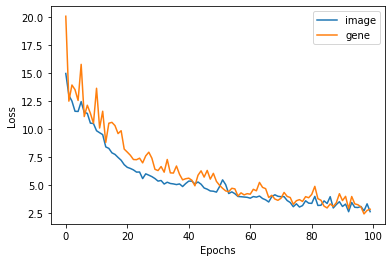

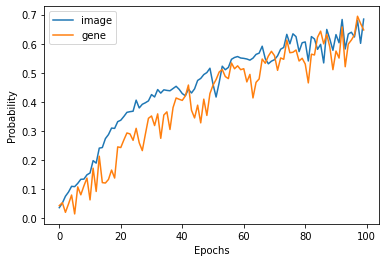

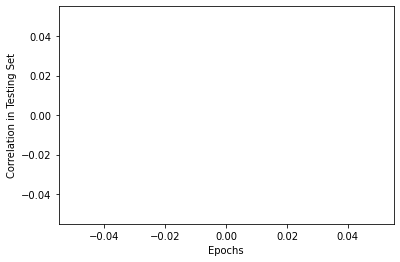

In [53]:
plt.plot(np.arange(len(hist['image_loss'])), hist['image_loss'])
plt.plot(np.arange(len(hist['gene_loss'])), hist['gene_loss'])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["image", "gene"])
plt.show()
plt.plot(np.arange(len(hist['image_prob'])), hist['image_prob'])
plt.plot(np.arange(len(hist['gene_prob'])), hist['gene_prob'])
plt.xlabel("Epochs")
plt.ylabel("Probability")
plt.legend(["image", "gene"])
plt.show()
plt.plot(hist['corr_val'])
plt.xlabel("Epochs")
plt.ylabel("Correlation in Testing Set")
plt.show()

In [54]:
print("Saving model...")
state = { 'model': model.state_dict(),
          'contrast': contrast.state_dict(),
          'optimizer': optimizer.state_dict(),
          'epoch': epoch}
torch.save(state, os.path.join(model_dir, "epoch_{}.pt".format(epoch)))
torch.save(hist, os.path.join(model_dir, "hist_continue.pt"))

Saving model...


In [ ]:
np.argmax(hist['corr_val'])

# Session Info

In [58]:
!pip freeze

absl-py==0.7.0
adjustText==0.7.3
altair==3.2.0
anndata==0.7.5
argh==0.26.2
ase==3.21.1
astor==0.7.1
astropy==3.2.1
atomicwrites==1.3.0
attrs==19.1.0
autograd==1.3
autograd-gamma==0.5.0
backcall==0.1.0
base58==1.0.3
bleach==1.5.0
blinker==1.4
boto3==1.10.15
botocore==1.13.15
Bottleneck==1.2.1
cachetools==4.1.0
certifi==2019.3.9
chardet==3.0.4
Click==7.0
cvxopt==1.2.3
cvxpy==1.0.24
cycler==0.10.0
Cython==0.29.15
dataclasses==0.8
decorator==4.4.0
defusedxml==0.5.0
dill==0.2.9
docutils==0.15.2
ecos==2.0.7.post1
entrypoints==0.3
enum-compat==0.0.3
environment-kernels==1.1.1
FITS-tools==0.2
formulaic==0.2.4
future==0.17.1
gast==0.2.2
get-version==2.1
google-auth==1.14.3
google-auth-oauthlib==0.4.1
google-pasta==0.2.0
googledrivedownloader==0.4
grpcio==1.29.0
h5py==2.10.0
html5lib==0.9999999
idna==2.8
image-registration==0.2.4
imageio==2.6.1
importlib-metadata==0.23
interface-meta==1.2.3
ipykernel==5.1.0
ipython==7.4.0
ipython-genutils==0.2.0
ipywidgets==7.4.2
isodate==0.6.0
jedi==0.13.3
Jinj